# Fase 2.2 — Variaciones de Partición
**Objetivo:** Evaluar la estabilidad de los modelos SVM y Random Forest bajo distintos esquemas de partición de datos.

Se realizan tres experimentos:
1. Particiones fijas: 70/30 y 60/40
2. Validación cruzada estratificada 5-Fold
3. Bootstrap (200 iteraciones)

Se reporta **media ± desviación estándar** de Accuracy, F1-Macro y F1-Weighted.

## 0. Imports y configuración

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils import resample
from sklearn.base import clone

print('Librerías cargadas correctamente ✓')

Librerías cargadas correctamente ✓


## 1. Carga y preparación de datos

In [2]:
df = pd.read_csv(r"../data_test/NHANES_2017_2020_labeled_diseases.csv")

print(f'Shape del dataset: {df.shape}')
print(f'\nColumnas: {list(df.columns)}')
print(f'\nDistribución de clases:')
print(df['condition'].value_counts())

Shape del dataset: (4812, 11)

Columnas: ['Platelets', 'White Blood Cells', 'Red Blood Cells', 'Hematocrit', 'Mean Corpuscular Volume', 'Mean Corpuscular Hemoglobin', 'Mean Corpuscular Hemoglobin Concentration', 'HDL Cholesterol', 'ALT', 'Heart Rate', 'condition']

Distribución de clases:
condition
healthy             3766
borderline           410
thalassemia          347
thrombocytopenia     204
anemia                85
Name: count, dtype: int64


In [3]:
TARGET_COL = 'condition'

X = df.drop(columns=[TARGET_COL])
X = X.select_dtypes(include=[np.number])

# Revisar NaN
print('NaN por columna:')
print(X.isna().sum())
print(f'\nTotal NaN: {X.isna().sum().sum()}')
print(f'Filas con al menos un NaN: {X.isna().any(axis=1).sum()}')

# Codificar etiquetas
le = LabelEncoder()
y = le.fit_transform(df[TARGET_COL])

print(f'\nFeatures utilizadas: {X.shape[1]}')
print(f'Clases: {list(le.classes_)}')
print(f'Total de registros: {len(y)}')

NaN por columna:
Platelets                                      0
White Blood Cells                              0
Red Blood Cells                                0
Hematocrit                                     0
Mean Corpuscular Volume                        0
Mean Corpuscular Hemoglobin                    0
Mean Corpuscular Hemoglobin Concentration      0
HDL Cholesterol                              153
ALT                                          176
Heart Rate                                   798
dtype: int64

Total NaN: 1127
Filas con al menos un NaN: 948

Features utilizadas: 10
Clases: ['anemia', 'borderline', 'healthy', 'thalassemia', 'thrombocytopenia']
Total de registros: 4812


## 2. Definición de modelos

Cada pipeline tiene tres pasos:
1. **Imputación** con mediana — rellena los NaN
2. **Escalado** — normaliza los valores para SVM
3. **Clasificador** — SVM o Random Forest

In [4]:
pipe_svm = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('clf',     SVC(kernel='rbf', C=10, gamma='scale', random_state=42))
])

pipe_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('clf',     RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

modelos = {
    'SVM (RBF)'    : pipe_svm,
    'Random Forest': pipe_rf
}

print('Modelos definidos con imputación de medianas ✓')

Modelos definidos con imputación de medianas ✓


## 3. Experimento 1 — Particiones fijas (70/30 y 60/40)

In [5]:
resultados_particion = []

for split_name, test_size in [('70/30', 0.30), ('60/40', 0.40)]:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )
    
    for nombre, pipeline in modelos.items():
        pipe_copy = clone(pipeline)
        pipe_copy.fit(X_train, y_train)
        y_pred = pipe_copy.predict(X_test)
        
        acc    = accuracy_score(y_test, y_pred)
        f1_mac = f1_score(y_test, y_pred, average='macro',    zero_division=0)
        f1_w   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        
        resultados_particion.append({
            'Experimento': f'Partición {split_name}',
            'Modelo'     : nombre,
            'Accuracy'   : round(acc,    4),
            'F1-Macro'   : round(f1_mac, 4),
            'F1-Weighted': round(f1_w,   4),
            'Train size' : len(y_train),
            'Test size'  : len(y_test)
        })
        print(f'{split_name} | {nombre:15s} → Acc: {acc:.4f} | F1-Mac: {f1_mac:.4f} | F1-W: {f1_w:.4f}')

df_particion = pd.DataFrame(resultados_particion)
print('\n✓ Experimento 1 completado')

70/30 | SVM (RBF)       → Acc: 0.9404 | F1-Mac: 0.8201 | F1-W: 0.9404
70/30 | Random Forest   → Acc: 0.9993 | F1-Mac: 0.9991 | F1-W: 0.9993
60/40 | SVM (RBF)       → Acc: 0.9361 | F1-Mac: 0.8126 | F1-W: 0.9367
60/40 | Random Forest   → Acc: 0.9995 | F1-Mac: 0.9993 | F1-W: 0.9995

✓ Experimento 1 completado


## 4. Experimento 2 — Validación Cruzada Estratificada 5-Fold

In [6]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy'   : 'accuracy',
    'f1_macro'   : 'f1_macro',
    'f1_weighted': 'f1_weighted'
}

resultados_cv = []

for nombre, pipeline in modelos.items():
    print(f'Corriendo 5-Fold CV para {nombre}...')
    cv_results = cross_validate(pipeline, X, y, cv=skf, scoring=scoring, n_jobs=-1)
    
    acc_scores = cv_results['test_accuracy']
    f1m_scores = cv_results['test_f1_macro']
    f1w_scores = cv_results['test_f1_weighted']
    
    resultados_cv.append({
        'Experimento': '5-Fold CV Estratificado',
        'Modelo'     : nombre,
        'Accuracy'   : f'{acc_scores.mean():.4f} ± {acc_scores.std():.4f}',
        'F1-Macro'   : f'{f1m_scores.mean():.4f} ± {f1m_scores.std():.4f}',
        'F1-Weighted': f'{f1w_scores.mean():.4f} ± {f1w_scores.std():.4f}',
        'acc_scores' : acc_scores,
        'f1m_scores' : f1m_scores
    })
    
    print(f'  Accuracy : {acc_scores.mean():.4f} ± {acc_scores.std():.4f}')
    print(f'  F1-Macro : {f1m_scores.mean():.4f} ± {f1m_scores.std():.4f}')
    print(f'  F1-W     : {f1w_scores.mean():.4f} ± {f1w_scores.std():.4f}\n')

print('✓ Experimento 2 completado')

Corriendo 5-Fold CV para SVM (RBF)...
  Accuracy : 0.9528 ± 0.0053
  F1-Macro : 0.8557 ± 0.0137
  F1-W     : 0.9527 ± 0.0053

Corriendo 5-Fold CV para Random Forest...
  Accuracy : 0.9983 ± 0.0008
  F1-Macro : 0.9973 ± 0.0020
  F1-W     : 0.9983 ± 0.0008

✓ Experimento 2 completado


## 5. Experimento 3 — Bootstrap (200 iteraciones)

In [7]:
N_BOOTSTRAP = 200
resultados_bootstrap = []
bootstrap_scores = {nombre: {'acc': [], 'f1_mac': [], 'f1_w': []} for nombre in modelos}

np.random.seed(42)
indices = np.arange(len(y))

for i in range(N_BOOTSTRAP):
    boot_idx = resample(indices, replace=True, random_state=i)
    oob_idx  = np.array(list(set(indices) - set(boot_idx)))
    
    if len(oob_idx) == 0 or len(np.unique(y[oob_idx])) < 2:
        continue
    
    X_boot = X.iloc[boot_idx]
    y_boot = y[boot_idx]
    X_oob  = X.iloc[oob_idx]
    y_oob  = y[oob_idx]
    
    for nombre, pipeline in modelos.items():
        model_copy = clone(pipeline)
        model_copy.fit(X_boot, y_boot)
        y_pred = model_copy.predict(X_oob)
        
        bootstrap_scores[nombre]['acc'].append(accuracy_score(y_oob, y_pred))
        bootstrap_scores[nombre]['f1_mac'].append(f1_score(y_oob, y_pred, average='macro',    zero_division=0))
        bootstrap_scores[nombre]['f1_w'].append(  f1_score(y_oob, y_pred, average='weighted', zero_division=0))
    
    if (i + 1) % 50 == 0:
        print(f'  Bootstrap {i+1}/{N_BOOTSTRAP} completado...')

for nombre in modelos:
    acc_arr = np.array(bootstrap_scores[nombre]['acc'])
    f1m_arr = np.array(bootstrap_scores[nombre]['f1_mac'])
    f1w_arr = np.array(bootstrap_scores[nombre]['f1_w'])
    
    ci_low  = np.percentile(acc_arr, 2.5)
    ci_high = np.percentile(acc_arr, 97.5)
    
    resultados_bootstrap.append({
        'Experimento'    : f'Bootstrap (n={N_BOOTSTRAP})',
        'Modelo'         : nombre,
        'Accuracy'       : f'{acc_arr.mean():.4f} ± {acc_arr.std():.4f}',
        'F1-Macro'       : f'{f1m_arr.mean():.4f} ± {f1m_arr.std():.4f}',
        'F1-Weighted'    : f'{f1w_arr.mean():.4f} ± {f1w_arr.std():.4f}',
        'IC 95% Accuracy': f'[{ci_low:.4f}, {ci_high:.4f}]',
        'acc_arr'        : acc_arr,
        'f1m_arr'        : f1m_arr
    })
    
    print(f'\n{nombre}')
    print(f'  Accuracy   : {acc_arr.mean():.4f} ± {acc_arr.std():.4f}  IC 95%: [{ci_low:.4f}, {ci_high:.4f}]')
    print(f'  F1-Macro   : {f1m_arr.mean():.4f} ± {f1m_arr.std():.4f}')
    print(f'  F1-Weighted: {f1w_arr.mean():.4f} ± {f1w_arr.std():.4f}')

print('\n✓ Experimento 3 completado')

  Bootstrap 50/200 completado...
  Bootstrap 100/200 completado...
  Bootstrap 150/200 completado...
  Bootstrap 200/200 completado...

SVM (RBF)
  Accuracy   : 0.9469 ± 0.0050  IC 95%: [0.9371, 0.9555]
  F1-Macro   : 0.8423 ± 0.0156
  F1-Weighted: 0.9468 ± 0.0050

Random Forest
  Accuracy   : 0.9985 ± 0.0011  IC 95%: [0.9961, 1.0000]
  F1-Macro   : 0.9974 ± 0.0023
  F1-Weighted: 0.9985 ± 0.0011

✓ Experimento 3 completado


## 6. Tabla resumen final

In [8]:
filas = []

for r in resultados_particion:
    filas.append({
        'Experimento'    : r['Experimento'],
        'Modelo'         : r['Modelo'],
        'Accuracy'       : str(r['Accuracy']),
        'F1-Macro'       : str(r['F1-Macro']),
        'F1-Weighted'    : str(r['F1-Weighted']),
        'IC 95% Accuracy': 'N/A'
    })

for r in resultados_cv:
    filas.append({
        'Experimento'    : r['Experimento'],
        'Modelo'         : r['Modelo'],
        'Accuracy'       : r['Accuracy'],
        'F1-Macro'       : r['F1-Macro'],
        'F1-Weighted'    : r['F1-Weighted'],
        'IC 95% Accuracy': 'Ver Bootstrap'
    })

for r in resultados_bootstrap:
    filas.append({
        'Experimento'    : r['Experimento'],
        'Modelo'         : r['Modelo'],
        'Accuracy'       : r['Accuracy'],
        'F1-Macro'       : r['F1-Macro'],
        'F1-Weighted'    : r['F1-Weighted'],
        'IC 95% Accuracy': r['IC 95% Accuracy']
    })

df_resumen = pd.DataFrame(filas)

print('='*100)
print('TABLA RESUMEN — FASE 2.2 Variaciones de Partición')
print('='*100)
print(df_resumen.to_string(index=False))

df_resumen.to_csv('../resultados_fase2_2.csv', index=False)
print('\n✓ Tabla guardada en resultados_fase2_2.csv')

TABLA RESUMEN — FASE 2.2 Variaciones de Partición
            Experimento        Modelo        Accuracy        F1-Macro     F1-Weighted  IC 95% Accuracy
        Partición 70/30     SVM (RBF)          0.9404          0.8201          0.9404              N/A
        Partición 70/30 Random Forest          0.9993          0.9991          0.9993              N/A
        Partición 60/40     SVM (RBF)          0.9361          0.8126          0.9367              N/A
        Partición 60/40 Random Forest          0.9995          0.9993          0.9995              N/A
5-Fold CV Estratificado     SVM (RBF) 0.9528 ± 0.0053 0.8557 ± 0.0137 0.9527 ± 0.0053    Ver Bootstrap
5-Fold CV Estratificado Random Forest 0.9983 ± 0.0008 0.9973 ± 0.0020 0.9983 ± 0.0008    Ver Bootstrap
      Bootstrap (n=200)     SVM (RBF) 0.9469 ± 0.0050 0.8423 ± 0.0156 0.9468 ± 0.0050 [0.9371, 0.9555]
      Bootstrap (n=200) Random Forest 0.9985 ± 0.0011 0.9974 ± 0.0023 0.9985 ± 0.0011 [0.9961, 1.0000]

✓ Tabla guardada en re

## 7. Visualizaciones

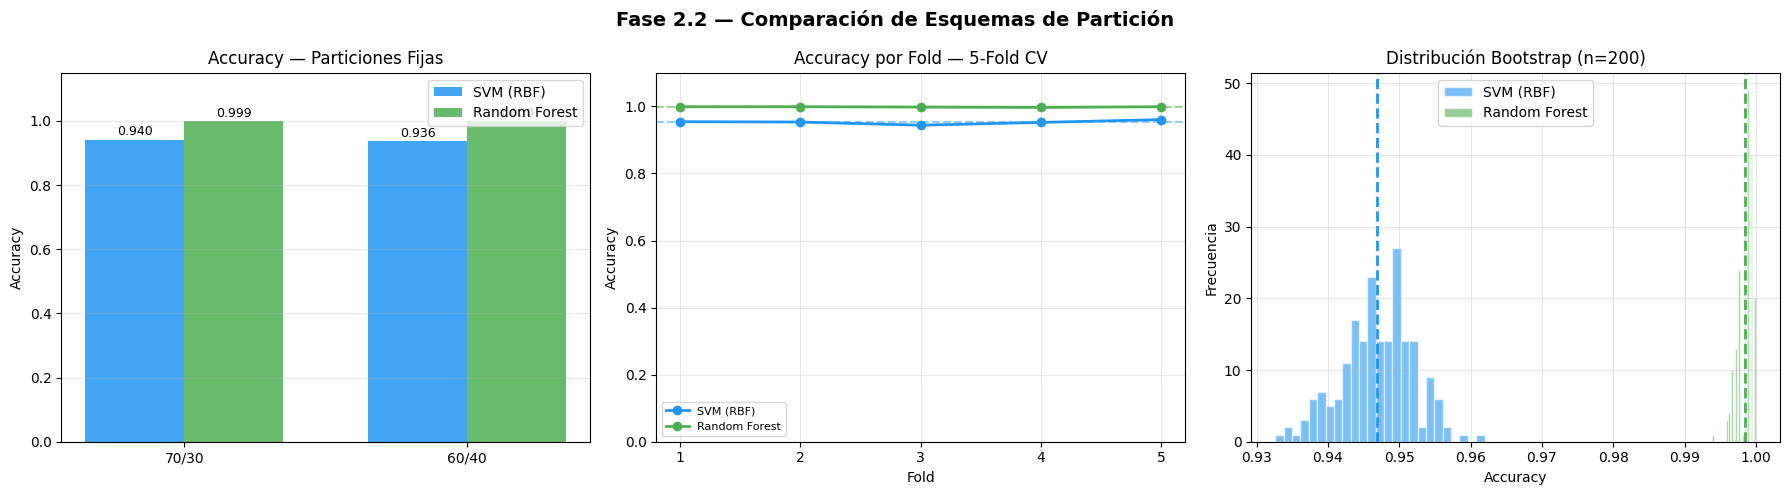

✓ Gráfica guardada en img/fase2_2_variaciones_particion.png


In [9]:
os.makedirs('../img', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Fase 2.2 — Comparación de Esquemas de Partición', fontsize=14, fontweight='bold')

colores = {'SVM (RBF)': '#2196F3', 'Random Forest': '#4CAF50'}

# Gráfica 1: Particiones fijas
ax1 = axes[0]
x = np.arange(2)
width = 0.35
splits = ['Partición 70/30', 'Partición 60/40']

for i, (nombre, color) in enumerate(colores.items()):
    vals = [
        df_particion[(df_particion['Experimento']==s) & (df_particion['Modelo']==nombre)]['Accuracy'].values[0]
        for s in splits
    ]
    bars = ax1.bar(x + i*width, vals, width, label=nombre, color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=9)

ax1.set_xticks(x + width/2)
ax1.set_xticklabels(['70/30', '60/40'])
ax1.set_ylim(0, 1.15)
ax1.set_title('Accuracy — Particiones Fijas')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Gráfica 2: 5-Fold CV
ax2 = axes[1]
for nombre, color in colores.items():
    r = next(r for r in resultados_cv if r['Modelo'] == nombre)
    ax2.plot(range(1, 6), r['acc_scores'], marker='o', label=nombre, color=color, linewidth=2)
    ax2.axhline(r['acc_scores'].mean(), color=color, linestyle='--', alpha=0.5)

ax2.set_xticks(range(1, 6))
ax2.set_xlabel('Fold')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy por Fold — 5-Fold CV')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)
ax2.set_ylim(0, 1.1)

# Gráfica 3: Bootstrap
ax3 = axes[2]
for nombre, color in colores.items():
    r = next(r for r in resultados_bootstrap if r['Modelo'] == nombre)
    ax3.hist(r['acc_arr'], bins=25, alpha=0.6, color=color, label=nombre, edgecolor='white')
    ax3.axvline(r['acc_arr'].mean(), color=color, linestyle='--', linewidth=2)

ax3.set_xlabel('Accuracy')
ax3.set_ylabel('Frecuencia')
ax3.set_title(f'Distribución Bootstrap (n={N_BOOTSTRAP})')
ax3.legend()
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../img/fase2_2_variaciones_particion.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Gráfica guardada en img/fase2_2_variaciones_particion.png')

## 8. Interpretación de resultados

In [10]:
print('='*60)
print('INTERPRETACIÓN AUTOMÁTICA DE RESULTADOS')
print('='*60)

for nombre in modelos:
    r_boot = next(r for r in resultados_bootstrap if r['Modelo'] == nombre)
    r_cv   = next(r for r in resultados_cv        if r['Modelo'] == nombre)
    
    acc_std_boot = r_boot['acc_arr'].std()
    acc_std_cv   = r_cv['acc_scores'].std()
    
    print(f'\n{nombre}:')
    
    if acc_std_boot < 0.01:
        print(f'  ✓ Modelo MUY ESTABLE           (std Bootstrap = {acc_std_boot:.4f} < 0.01)')
    elif acc_std_boot < 0.03:
        print(f'  ~ Modelo MODERADAMENTE ESTABLE (std Bootstrap = {acc_std_boot:.4f})')
    else:
        print(f'  ✗ Modelo INESTABLE             (std Bootstrap = {acc_std_boot:.4f} > 0.03)')
    
    if acc_std_cv < 0.02:
        print(f'  ✓ Consistente entre folds      (std CV = {acc_std_cv:.4f})')
    else:
        print(f'  ~ Variación entre folds notable (std CV = {acc_std_cv:.4f})')

print('\n' + '='*60)
print('Fase 2.2 completada ✓')
print('Archivos generados:')
print('  - resultados_fase2_2.csv')
print('  - img/fase2_2_variaciones_particion.png')

INTERPRETACIÓN AUTOMÁTICA DE RESULTADOS

SVM (RBF):
  ✓ Modelo MUY ESTABLE           (std Bootstrap = 0.0050 < 0.01)
  ✓ Consistente entre folds      (std CV = 0.0053)

Random Forest:
  ✓ Modelo MUY ESTABLE           (std Bootstrap = 0.0011 < 0.01)
  ✓ Consistente entre folds      (std CV = 0.0008)

Fase 2.2 completada ✓
Archivos generados:
  - resultados_fase2_2.csv
  - img/fase2_2_variaciones_particion.png
